In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


In [4]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(path + "/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [68]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['overall_pass'] = (df['total_score'] >= 180).astype(int)
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,overall_pass
0,female,group B,bachelor's degree,standard,none,72,72,74,218,1
1,female,group C,some college,standard,completed,69,90,88,247,1
2,female,group B,master's degree,standard,none,90,95,93,278,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,0
4,male,group C,some college,standard,none,76,78,75,229,1


In [69]:
X = df.drop(['math score', 'reading score', 'writing score', 'total_score', 'overall_pass'], axis=1)
y = df['overall_pass']

In [70]:
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (700, 12)
X_test shape: (300, 12)
y_train shape: (700,)
y_test shape: (300,)


In [71]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   gender_male                                    1000 non-null   bool 
 1   race/ethnicity_group B                         1000 non-null   bool 
 2   race/ethnicity_group C                         1000 non-null   bool 
 3   race/ethnicity_group D                         1000 non-null   bool 
 4   race/ethnicity_group E                         1000 non-null   bool 
 5   parental level of education_bachelor's degree  1000 non-null   bool 
 6   parental level of education_high school        1000 non-null   bool 
 7   parental level of education_master's degree    1000 non-null   bool 
 8   parental level of education_some college       1000 non-null   bool 
 9   parental level of education_some high school   1000 non-null   bool 
 10  l

In [72]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [73]:
y_pred = tree.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6233333333333333


In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.40      0.40        94
           1       0.73      0.72      0.73       206

    accuracy                           0.62       300
   macro avg       0.56      0.56      0.56       300
weighted avg       0.62      0.62      0.62       300



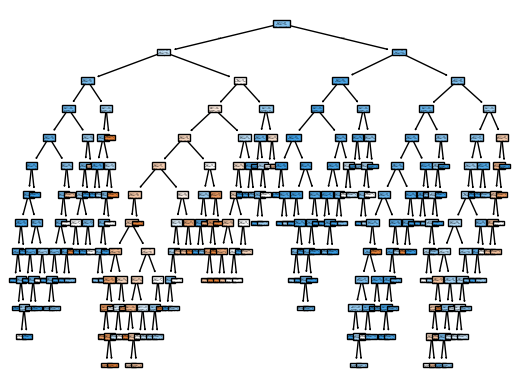

In [76]:
plot_tree(tree, filled=True)
plt.show()

In [77]:
# Find similar rows in your actual dataset
similar = df[
    (df['gender'] == 'male') &
    (df['race/ethnicity'] == 'group A') &
    (df['lunch'] == 'free/reduced') &
    (df['test preparation course'] == 'none')
]
print(similar[['total_score', 'overall_pass']])
print("\nPass rate for this group:", similar['overall_pass'].mean())

     total_score  overall_pass
3            148             0
25           219             1
61           112             0
62           178             0
228          204             1
327           70             0
395          134             0
428          177             0
444          234             1
688          155             0
705          199             1
731          144             0
769          175             0
805          230             1
811          141             0

Pass rate for this group: 0.3333333333333333


In [52]:
import numpy as np

In [78]:
my_data = pd.DataFrame([{
    'gender_male': False,                                          # True if male, False if female
    'race/ethnicity_group B': True,
    'race/ethnicity_group C': False,                               # Set True for your group
    'race/ethnicity_group D': False,
    'race/ethnicity_group E': False,
    'parental level of education_bachelor\'s degree': False,
    'parental level of education_high school': True,
    'parental level of education_master\'s degree': False,
    'parental level of education_some college': False,             # Set True for your education
    'parental level of education_some high school': False,
    'lunch_standard': False,                                       # True if standard, False if free/reduced
    'test preparation course_none': True                         # True if no prep, False if completed
}])

prediction = tree.predict(my_data)
print("Pass (1) or Fail (0):", prediction[0])

Pass (1) or Fail (0): 1


In [79]:
# Check probability instead of hard prediction
proba = tree.predict_proba(my_data)
print(f"Probability of Fail (0): {proba[0][0]:.2f}")
print(f"Probability of Pass (1): {proba[0][1]:.2f}")

Probability of Fail (0): 0.25
Probability of Pass (1): 0.75


## Regression

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv(path + "/StudentsPerformance.csv")

In [81]:
X = df[['reading score', 'writing score']]
y = df['math score']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train both models
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Evaluate
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

In [82]:
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))
print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))

Linear Regression R2: 0.6825697127424626
Decision Tree R2: 0.6560675857257199
Linear Regression MSE: 77.24297821278955
Decision Tree MSE: 83.6919633976405


In [83]:
my_student = pd.DataFrame([{
    'reading score': 57,
    'writing score': 44
}])

print("Linear Regression prediction:", lr.predict(my_student)[0])
print("Decision Tree prediction:", dt.predict(my_student)[0])
print("Actual math score:", 47)

Linear Regression prediction: 52.623828437003745
Decision Tree prediction: 49.86363636363637
Actual math score: 47
